In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
import warnings
warnings.filterwarnings("ignore")

In [63]:
df_train = pd.read_csv("/content/train_KNN.csv")
df_test = pd.read_csv("/content/test_KNN.csv")

In [64]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [65]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [66]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [67]:
mp = 100*(df_train.isnull().sum()/len(df_train))
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [68]:
mp = mp[mp>0].sort_values()
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [69]:
df_train["Age"].median()

28.0

In [70]:
df_train["Fare"].median()

14.4542

In [71]:
df_train[df_train["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [72]:
df_train = df_train.dropna(axis = 0, subset= ["Embarked"])

In [73]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [74]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [75]:
df_train = df_train.drop(["Cabin"], axis = 1) ## 1 is for column (axis)

In [76]:
mpt = 100*(df_test.isnull().sum()/len(df_test))
mpt

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [77]:
mpt = mpt[mpt>0].sort_values()
mpt

,0
Fare,0.239234
Age,20.574163
Cabin,78.229665


In [78]:
df_test[df_test["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [79]:
df_test = df_test.dropna(axis = 0, subset= ["Fare"])

In [80]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Survived     417 non-null    int64  
 2   Pclass       417 non-null    int64  
 3   Name         417 non-null    object 
 4   Sex          417 non-null    object 
 5   Age          331 non-null    float64
 6   SibSp        417 non-null    int64  
 7   Parch        417 non-null    int64  
 8   Ticket       417 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     417 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 42.4+ KB


In [81]:
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

In [82]:
df_test = df_test.drop(["Cabin"], axis = 1)

In [24]:
df_train.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)

In [83]:
df_test.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)

In [84]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [85]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  417 non-null    int64  
 1   Pclass    417 non-null    int64  
 2   Sex       417 non-null    object 
 3   Age       417 non-null    float64
 4   SibSp     417 non-null    int64  
 5   Parch     417 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  417 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 29.3+ KB


In [86]:
df_train["Survived"] = df_train["Survived"].apply(str)

In [87]:
df_train["Pclass"] = df_train["Pclass"].apply(str)

In [88]:
df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)

In [91]:
df_train_num = df_train.select_dtypes(exclude = "object")
df_train_obj = df_train.select_dtypes(include = "object")

In [92]:
df_test_num = df_test.select_dtypes(exclude = "object")
df_test_obj = df_test.select_dtypes(include = "object")

In [93]:
df_train_num.columns

Index(['PassengerId', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [94]:
df_train_obj = pd.get_dummies(df_train_obj, drop_first = True)

In [95]:
df_test_obj = pd.get_dummies(df_test_obj, drop_first = True)

In [96]:
df_test_obj.columns

Index(['Survived_1', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [98]:
Final_train_df = pd.concat([df_train_num, df_train_obj, df_train["Survived"]], axis=1)
Final_train_df.head()

,PassengerId,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)",...,Ticket_W./C. 14263,Ticket_W./C. 6607,Ticket_W./C. 6608,Ticket_W./C. 6609,Ticket_W.E.P. 5734,Ticket_W/C 14208,Ticket_WE/P 5735,Embarked_Q,Embarked_S,Survived
0,1,22.0,1,0,7.2500,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,0
1,2,38.0,1,0,71.2833,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
2,3,26.0,0,0,7.9250,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,1
3,4,35.0,1,0,53.1000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1
4,5,35.0,0,0,8.0500,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,0


In [99]:
Final_test_df = pd.concat([df_test_num, df_test_obj, df_test["Survived"]], axis=1)
Final_test_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,34.5,0,0,7.8292,False,False,True,True,True,False,0
1,47.0,1,0,7.0000,True,False,True,False,False,True,1
2,62.0,0,0,9.6875,False,True,False,True,True,False,0
3,27.0,0,0,8.6625,False,False,True,True,False,True,0
4,22.0,1,1,12.2875,True,False,True,False,False,True,1


In [100]:
#### Standardize the data
### Define X train and Y train
X_train = Final_train_df.drop("Survived", axis =1)

In [101]:
y_train = Final_train_df["Survived"]

In [102]:
y_tes = Final_test_df["Survived"]

In [108]:
X_test = Final_test_df.drop("Survived", axis = 1)

In [104]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [105]:
scaled_X_train = scaler.transform(X_train)

In [109]:
train_cols = X_train.columns

# Add missing columns to X_test and fill with 0
missing_cols_in_test = set(train_cols) - set(X_test.columns)
for c in missing_cols_in_test:
    X_test[c] = 0

# Ensure the order of columns in X_test is the same as in X_train
X_test = X_test[train_cols]

scaled_X_test = scaler.transform(X_test)

In [110]:
knn = KNeighborsClassifier(n_neighbors=5)

In [111]:
knn.fit(scaled_X_train, y_train)

KNeighborsClassifier()

In [112]:
y_pred = knn.predict(scaled_X_test)

In [113]:
accuracy_score(y_tes, y_pred)

0.3645083932853717

In [114]:
# Finding the optimal K value
# Checking with different values of K
Performance_Metric = []

for k in range(1,30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    y_pred_k = knn_k.predict(scaled_X_test)
    accuracy_k = 1 - accuracy_score(y_tes, y_pred_k)
    Performance_Metric.append(accuracy_k)

In [115]:
Performance_Metric

[0.29496402877697847,
 0.17985611510791366,
 0.6354916067146283,
 0.6354916067146283,
 0.6354916067146283,
 0.6330935251798562,
 0.6330935251798562,
 0.6330935251798562,
 0.6235011990407674,
 0.6330935251798562,
 0.630695443645084,
 0.618705035971223,
 0.6235011990407674,
 0.6067146282973621,
 0.618705035971223,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.3621103117505995,
 0.36450839328537166,
 0.36450839328537166,
 0.36450839328537166,
 0.36450839328537166]

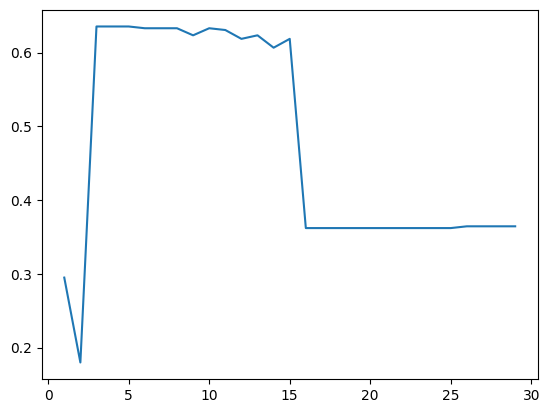

In [116]:
plt.plot(range(1,30), Performance_Metric)

In [117]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(scaled_X_train, y_train)
y_pred_lr = lr.predict(scaled_X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_tes, y_pred_lr))

Logistic Regression Accuracy: 1.0


In [118]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(scaled_X_train, y_train)
y_pred_dt = dt.predict(scaled_X_test)
print("Decision Tree Accuracy:", accuracy_score(y_tes, y_pred_dt))

Decision Tree Accuracy: 1.0


In [120]:
# Comparing their performance
knn_acc = accuracy_score(y_tes, y_pred)
lr_acc = accuracy_score(y_tes, y_pred_lr)
dt_acc = accuracy_score(y_tes, y_pred_dt)
print("KNN Accuracy:", knn_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
results = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree"],
    "Accuracy": [knn_acc, lr_acc, dt_acc]
})

KNN Accuracy: 0.3645083932853717
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


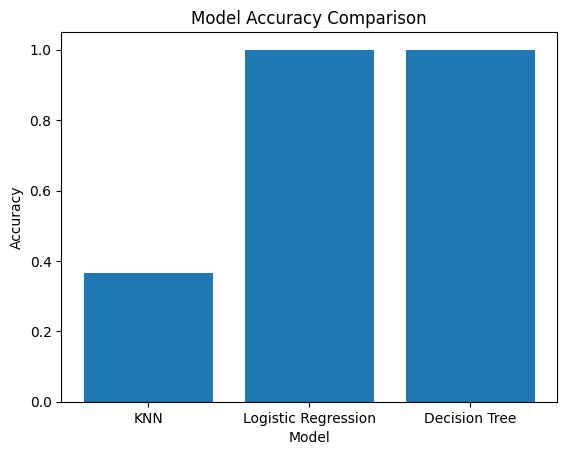

In [121]:
import matplotlib.pyplot as plt
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()